# Testy statystyczne w praktyce — wybór, założenia, interpretacja, pułapki

Notebook nie jest "ściągawką z komendami" — każda sekcja pokazuje **dlaczego**
wybrano dany test, jakie ma założenia, co się dzieje gdy są złamane, i jak
NIE interpretować wyniku. To odzwierciedla typowy problem w pracy
analitycznej: dobór złego testu albo poprawny test z błędną interpretacją
p-value psuje wnioski dokładnie tak samo jak błąd w SQL.

Biblioteki: `scipy.stats` (testy), `statsmodels` (ANOVA, post-hoc, regresja),
`numpy`/`pandas` (dane).

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(42)   # ziarno dla powtarzalności przykładów
sns.set_theme(style="whitegrid")

## 1. Podstawy — o co właściwie pyta test statystyczny

Test statystyczny odpowiada na jedno, wąskie pytanie: *"Jak zaskakujące
byłyby zaobserwowane dane, gdyby w rzeczywistości nie było żadnej różnicy/
zależności (hipoteza zerowa H0)?"*

- **H0 (hipoteza zerowa)** — "nie ma różnicy/efektu/zależności" (punkt
  odniesienia, który próbujesz obalić).
- **H1 (hipoteza alternatywna)** — to, co faktycznie Cię interesuje ("jest
  różnica").
- **p-value** — prawdopodobieństwo zaobserwowania różnicy co najmniej tak
  dużej jak w danych, **zakładając że H0 jest prawdziwe**. To NIE jest
  prawdopodobieństwo, że H0 jest prawdziwe ani że efekt istnieje.
- **Poziom istotności α** (zwykle 0.05) — próg, poniżej którego uznajemy
  wynik za "statystycznie istotny". To umowna konwencja, nie prawo natury.
- **Błąd I rodzaju** — odrzucenie prawdziwego H0 (fałszywy alarm).
- **Błąd II rodzaju** — nieodrzucenie fałszywego H0 (przeoczenie realnego
  efektu) — rośnie przy małej próbie (niska "moc testu").

Cały notebook wraca do jednej zasady: **wybór testu wynika z typu danych i
sprawdzonych założeń, nie z przyzwyczajenia** ("zawsze robię t-test").

## 2. Sprawdzenie założeń PRZED wyborem testu

Dwa założenia wracają w niemal każdym teście z sekcji 3-4: **normalność
rozkładu** i **jednorodność wariancji**. Sprawdzasz je najpierw wizualnie
(Q-Q plot, histogram), a formalnie — testem.

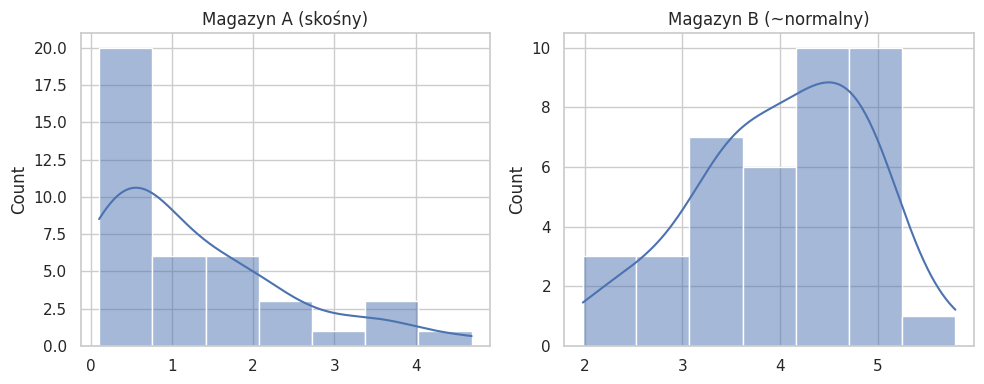

In [2]:
# dane przykładowe: czas realizacji zamówienia (dni) w dwóch magazynach
magazyn_a = rng.gamma(shape=1.0, scale=1.5, size=40)   # rozkład skośny (wykładniczy) — celowo NIE normalny
magazyn_b = rng.normal(loc=4, scale=1.2, size=40)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(magazyn_a, kde=True, ax=axes[0]).set_title("Magazyn A (skośny)")
sns.histplot(magazyn_b, kde=True, ax=axes[1]).set_title("Magazyn B (~normalny)")
plt.tight_layout()
plt.show()

In [3]:
# Shapiro-Wilk — formalny test normalności. H0: dane pochodzą z rozkładu normalnego.
# Działa dobrze dla n < ~5000; przy bardzo dużych próbach nawet trywialne odchylenia
# wychodzą "istotne" — wtedy bardziej polegaj na wykresie (Q-Q plot) niż na samym p-value.
shapiro_a = stats.shapiro(magazyn_a)
shapiro_b = stats.shapiro(magazyn_b)

print(f"Magazyn A: statystyka={shapiro_a.statistic:.3f}, p-value={shapiro_a.pvalue:.4f}")
print(f"Magazyn B: statystyka={shapiro_b.statistic:.3f}, p-value={shapiro_b.pvalue:.4f}")
# p < 0.05 -> odrzucamy normalność; magazyn A (rozkład gamma) powinien wyjść jako nie-normalny

Magazyn A: statystyka=0.857, p-value=0.0001
Magazyn B: statystyka=0.969, p-value=0.3365


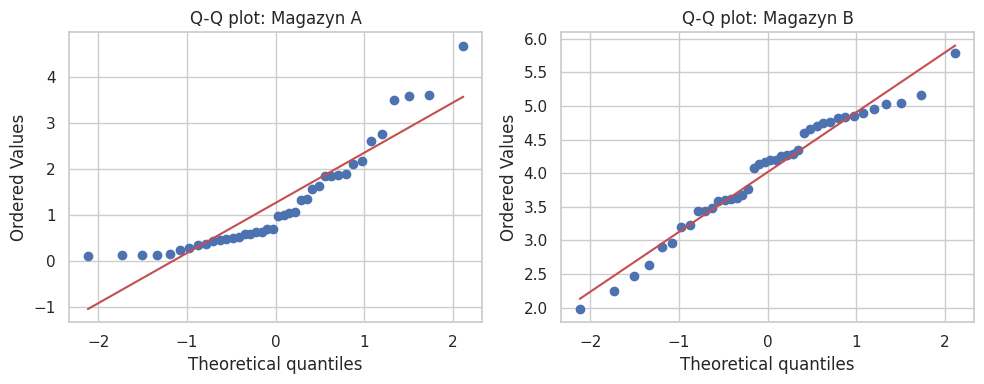

In [4]:
# Q-Q plot — wizualna kontrola, dużo bardziej informacyjna niż sam p-value Shapiro-Wilka.
# Punkty leżące na linii prostej = zgodność z rozkładem normalnym.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(magazyn_a, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot: Magazyn A")
stats.probplot(magazyn_b, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot: Magazyn B")
plt.tight_layout()
plt.show()

In [5]:
# Levene — test jednorodności wariancji (homoscedastyczności). H0: wariancje równe.
# Ważne dla klasycznego t-testu Studenta i ANOVA — patrz sekcja 3.
levene_wynik = stats.levene(magazyn_a, magazyn_b)
print(f"Levene: statystyka={levene_wynik.statistic:.3f}, p-value={levene_wynik.pvalue:.4f}")

Levene: statystyka=0.988, p-value=0.3234


## 3. Porównanie DWÓCH grup

### a) t-test dla prób niezależnych — Student vs Welch

- **t-test Studenta** — zakłada normalność w obu grupach ORAZ równe
  wariancje.
- **t-test Welcha** — jak Student, ale NIE zakłada równych wariancji
  (koryguje stopnie swobody). W praktyce: **Welch jako domyślny wybór** —
  jest niemal tak samo skuteczny jak Student gdy wariancje faktycznie są
  równe, a znacznie bezpieczniejszy gdy nie są. W `scipy` to jeden
  parametr (`equal_var`).

In [6]:
# grupy o podobnym rozkładzie (~normalne), różnej wariancji — typowy przypadek w danych biznesowych
grupa_kontrolna = rng.normal(loc=100, scale=15, size=60)
grupa_testowa = rng.normal(loc=108, scale=25, size=55)

# t-test Welcha (equal_var=False) — bezpieczny domyślny wybór
t_welch = stats.ttest_ind(grupa_kontrolna, grupa_testowa, equal_var=False)
print(f"Welch: t={t_welch.statistic:.3f}, p-value={t_welch.pvalue:.4f}")

# dla porównania: t-test Studenta (equal_var=True) — przy nierównych wariancjach może dać inny wynik
t_student = stats.ttest_ind(grupa_kontrolna, grupa_testowa, equal_var=True)
print(f"Student: t={t_student.statistic:.3f}, p-value={t_student.pvalue:.4f}")

Welch: t=-2.430, p-value=0.0172
Student: t=-2.483, p-value=0.0145


### b) Mann-Whitney U — nieparametryczny odpowiednik

Używaj, gdy założenie normalności jest wyraźnie złamane (jak `magazyn_a`
wyżej) i próba jest za mała, żeby polegać na centralnym twierdzeniu
granicznym (orientacyjnie n < 30 na grupę), albo dane są z natury
porządkowe (rankingi, oceny 1-5), nie ciągłe.

Ważne zastrzeżenie interpretacyjne: Mann-Whitney testuje, czy jedna zmienna
losowa ma tendencję do przyjmowania **większych wartości** niż druga
(dokładniej: porównuje dystrybuanty) — to **nie jest** test na różnicę
średnich, mimo że bywa tak potocznie opisywany.

In [7]:
mw_wynik = stats.mannwhitneyu(magazyn_a, magazyn_b, alternative="two-sided")
print(f"Mann-Whitney U: U={mw_wynik.statistic:.1f}, p-value={mw_wynik.pvalue:.4f}")

Mann-Whitney U: U=72.0, p-value=0.0000


### c) Dane sparowane (ten sam obiekt mierzony dwukrotnie) — t-test sparowany vs Wilcoxon

Typowy przykład: sprzedaż w tych samych sklepach przed/po zmianie
ekspozycji. Test sparowany ma dużo większą moc niż niesparowany, bo usuwa
zmienność MIĘDZY sklepami i skupia się wyłącznie na różnicy WEWNĄTRZ
każdej pary.

In [8]:
sprzedaz_przed = rng.normal(loc=500, scale=80, size=25)
efekt = rng.normal(loc=30, scale=20, size=25)   # każdy sklep zyskuje śr. +30, z własną zmiennością
sprzedaz_po = sprzedaz_przed + efekt

# t-test sparowany — zakłada normalność RÓŻNIC (sprzedaz_po - sprzedaz_przed), nie normalność samych grup
t_sparowany = stats.ttest_rel(sprzedaz_po, sprzedaz_przed)
print(f"t sparowany: t={t_sparowany.statistic:.3f}, p-value={t_sparowany.pvalue:.6f}")

# Wilcoxon signed-rank — nieparametryczny odpowiednik, gdy różnice nie są normalne
wilcoxon_wynik = stats.wilcoxon(sprzedaz_po, sprzedaz_przed)
print(f"Wilcoxon: statystyka={wilcoxon_wynik.statistic:.1f}, p-value={wilcoxon_wynik.pvalue:.6f}")

t sparowany: t=5.545, p-value=0.000011
Wilcoxon: statystyka=11.0, p-value=0.000003


## 4. Porównanie WIĘCEJ niż dwóch grup

### a) ANOVA jednoczynnikowa + post-hoc (Tukey HSD)

ANOVA odpowiada tylko na pytanie "czy JEST różnica gdzieś pomiędzy
grupami" — **nie mówi, które konkretnie grupy się różnią**. Do tego
potrzebny jest test post-hoc (np. Tukey HSD), wykonywany DOPIERO gdy ANOVA
wyjdzie istotna — uruchamianie testów parami bez ANOVA i bez korekty
(sekcja 6) zawyża odsetek fałszywych alarmów.

In [9]:
df_regiony = pd.DataFrame({
    "region": ["Polnoc"] * 30 + ["Poludnie"] * 30 + ["Centrum"] * 30,
    "sprzedaz": np.concatenate([
        rng.normal(100, 12, 30),
        rng.normal(108, 12, 30),
        rng.normal(115, 12, 30),
    ]),
})

anova_wynik = stats.f_oneway(
    df_regiony.loc[df_regiony["region"] == "Polnoc", "sprzedaz"],
    df_regiony.loc[df_regiony["region"] == "Poludnie", "sprzedaz"],
    df_regiony.loc[df_regiony["region"] == "Centrum", "sprzedaz"],
)
print(f"ANOVA: F={anova_wynik.statistic:.3f}, p-value={anova_wynik.pvalue:.4f}")

ANOVA: F=14.393, p-value=0.0000


In [10]:
# post-hoc TYLKO po istotnej ANOVIE — mówi, KTÓRE pary grup się różnią
tukey = pairwise_tukeyhsd(endog=df_regiony["sprzedaz"], groups=df_regiony["region"], alpha=0.05)
print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2  meandiff p-adj   lower    upper  reject
--------------------------------------------------------
Centrum   Polnoc -16.0317    0.0 -23.3961 -8.6673   True
Centrum Poludnie -11.6462 0.0009 -19.0106 -4.2818   True
 Polnoc Poludnie   4.3855 0.3352  -2.9789 11.7499  False
--------------------------------------------------------

### b) Kruskal-Wallis — nieparametryczny odpowiednik ANOVA

Jak Mann-Whitney jest nieparametrycznym odpowiednikiem t-testu, tak
Kruskal-Wallis jest odpowiednikiem ANOVA — stosuj przy złamanej normalności
w którejkolwiek z grup. Post-hoc do Kruskal-Wallisa to zwykle test Dunna
(porównania parami z korektą wielokrotnego testowania — poza `scipy`,
dostępny np. w `scikit-posthocs`).

In [11]:
kw_wynik = stats.kruskal(
    df_regiony.loc[df_regiony["region"] == "Polnoc", "sprzedaz"],
    df_regiony.loc[df_regiony["region"] == "Poludnie", "sprzedaz"],
    df_regiony.loc[df_regiony["region"] == "Centrum", "sprzedaz"],
)
print(f"Kruskal-Wallis: H={kw_wynik.statistic:.3f}, p-value={kw_wynik.pvalue:.4f}")

Kruskal-Wallis: H=22.692, p-value=0.0000


## 5. Zależności między zmiennymi KATEGORYCZNYMI

### Chi-kwadrat niezależności

Pytanie: "czy rozkład jednej zmiennej kategorycznej zależy od wartości
drugiej" (np. czy konwersja zależy od wariantu strony w A/B teście).
Założenie: liczności oczekiwane w każdej komórce tabeli kontyngencji ≥ 5
— poniżej tego progu wynik chi-kwadrat jest zawodny.

In [12]:
# tabela kontyngencji: wariant strony x czy klient dokonal zakupu
tabela = pd.DataFrame(
    [[180, 620], [230, 570]],
    index=["Wariant A", "Wariant B"],
    columns=["Zakup", "Brak zakupu"],
)
tabela

,Zakup,Brak zakupu
Wariant A,180,620
Wariant B,230,570


In [13]:
chi2, p_value, dof, oczekiwane = stats.chi2_contingency(tabela)
print(f"chi2={chi2:.3f}, p-value={p_value:.4f}, stopnie swobody={dof}")
print("Liczności oczekiwane (do weryfikacji założenia >= 5):")
print(pd.DataFrame(oczekiwane, index=tabela.index, columns=tabela.columns).round(1))

chi2=7.874, p-value=0.0050, stopnie swobody=1
Liczności oczekiwane (do weryfikacji założenia >= 5):
           Zakup  Brak zakupu
Wariant A  205.0        595.0
Wariant B  205.0        595.0


### Dokładny test Fishera — gdy liczności są małe

Gdy którakolwiek oczekiwana liczność < 5 (typowe przy rzadkich zdarzeniach
albo małej próbie), chi-kwadrat jest niewiarygodny — użyj dokładnego testu
Fishera (w `scipy` natywnie dla tabel 2x2).

In [14]:
tabela_mala = pd.DataFrame(
    [[3, 17], [8, 12]],
    index=["Wariant A", "Wariant B"],
    columns=["Zakup", "Brak zakupu"],
)

odds_ratio, p_value_fisher = stats.fisher_exact(tabela_mala)
print(f"iloraz szans={odds_ratio:.3f}, p-value={p_value_fisher:.4f}")

iloraz szans=0.265, p-value=0.1552


## 6. Korelacje — Pearson vs Spearman vs Kendall

| Test | Mierzy | Założenia | Kiedy używać |
|---|---|---|---|
| **Pearson** | zależność LINIOWĄ | obie zmienne w miarę normalne, związek liniowy | dane ciągłe, oczekiwany związek liniowy |
| **Spearman** | zależność MONOTONICZNĄ (niekoniecznie liniową) | brak — oparty na rangach | dane porządkowe, outliery, związek nieliniowy ale monotoniczny |
| **Kendall** | zgodność par rangowań (τ) | brak — oparty na rangach | małe próby, dużo wartości powtórzonych (ties) |

In [15]:
x = rng.normal(0, 1, 100)
y_liniowe = 2 * x + rng.normal(0, 0.5, 100)                    # związek liniowy
y_monotoniczne = np.exp(1.5 * x) + rng.normal(0, 0.5, 100)      # związek monotoniczny, silnie nieliniowy

pearson_lin = stats.pearsonr(x, y_liniowe)
spearman_lin = stats.spearmanr(x, y_liniowe)
pearson_mono = stats.pearsonr(x, y_monotoniczne)
spearman_mono = stats.spearmanr(x, y_monotoniczne)

print("Związek liniowy      -> Pearson r =", round(pearson_lin.statistic, 3), " Spearman rho =", round(spearman_lin.statistic, 3))
print("Związek monotoniczny -> Pearson r =", round(pearson_mono.statistic, 3), " Spearman rho =", round(spearman_mono.statistic, 3))
# przy związku nieliniowym Pearson wyraźnie zaniża siłę zależności względem Spearmana

Związek liniowy      -> Pearson r = 0.97  Spearman rho = 0.954
Związek monotoniczny -> Pearson r = 0.678  Spearman rho = 0.92


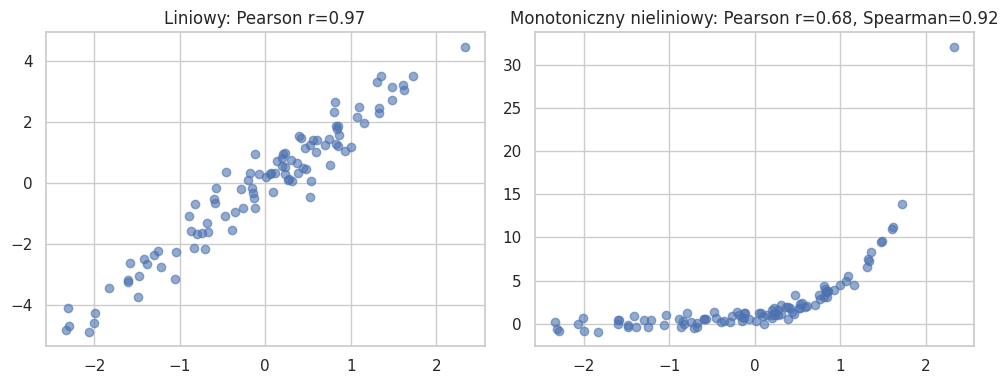

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(x, y_liniowe, alpha=0.6)
axes[0].set_title(f"Liniowy: Pearson r={pearson_lin.statistic:.2f}")
axes[1].scatter(x, y_monotoniczne, alpha=0.6)
axes[1].set_title(f"Monotoniczny nieliniowy: Pearson r={pearson_mono.statistic:.2f}, Spearman={spearman_mono.statistic:.2f}")
plt.tight_layout()
plt.show()

## 7. Wielkość efektu — dlaczego sam p-value nie wystarczy

p-value mówi "czy różnica prawdopodobnie nie jest przypadkiem", ale NIC nie
mówi o tym, **jak duża i ważna praktycznie** jest ta różnica. Przy
wystarczająco dużej próbie nawet trywialna, biznesowo nieistotna różnica
wyjdzie "statystycznie istotna" — poniżej dokładnie taki przypadek.

In [17]:
# dwie grupy różniące się o 0.5 punktu na skali ~100 — realnie nieistotne biznesowo
duza_proba_a = rng.normal(100.0, 15, 50_000)
duza_proba_b = rng.normal(100.5, 15, 50_000)

t_duza = stats.ttest_ind(duza_proba_a, duza_proba_b, equal_var=False)
print(f"p-value: {t_duza.pvalue:.6f}  <-- wygląda 'bardzo istotnie'")

# Cohen's d — standaryzowana wielkość efektu: (średnia1 - średnia2) / łączne odchylenie std
def cohens_d(a, b):
    n_a, n_b = len(a), len(b)
    var_a, var_b = np.var(a, ddof=1), np.var(b, ddof=1)
    wspolne_odchylenie = np.sqrt(((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2))
    return (np.mean(a) - np.mean(b)) / wspolne_odchylenie

d = cohens_d(duza_proba_a, duza_proba_b)
print(f"Cohen's d: {d:.4f}  <-- praktycznie zero (umowne progi: 0.2=mały, 0.5=średni, 0.8=duży)")

p-value: 0.000064  <-- wygląda 'bardzo istotnie'
Cohen's d: -0.0253  <-- praktycznie zero (umowne progi: 0.2=mały, 0.5=średni, 0.8=duży)


Cohen's d jest jedną z niewielu rzeczy w tym notebooku wartą trzymania jako
funkcja — liczysz go za każdym razem, gdy raportujesz wynik testu grupowego,
a wzór (wspólne odchylenie standardowe ważone licznością grup) łatwo
przekręcić przy ręcznym przepisywaniu.

**Zasada praktyczna do raportowania wyników:** zawsze podawaj p-value RAZEM
z wielkością efektu (i najlepiej przedziałem ufności dla różnicy średnich)
— sam p-value bez tego kontekstu to niepełna informacja.

## 8. Wielokrotne testowanie — dlaczego 20 testów przy α=0.05 to problem

Jeśli wykonasz 20 niezależnych testów, z których w rzeczywistości ŻADEN nie
ma prawdziwego efektu, przy α=0.05 **oczekiwana liczba fałszywych alarmów
to 1** (20 × 0.05). To dokładnie sytuacja "sprawdzam 20 segmentów klientów
pod kątem różnicy w konwersji" — bez korekty niemal na pewno "znajdziesz"
istotny wynik, który jest czystym szumem.

In [18]:
# symulacja: 20 testów, WSZYSTKIE grupy pochodzą z tego samego rozkładu (brak prawdziwego efektu)
p_values = []
for _ in range(20):
    a = rng.normal(0, 1, 30)
    b = rng.normal(0, 1, 30)   # ta sama średnia co 'a' -> H0 prawdziwe
    p_values.append(stats.ttest_ind(a, b).pvalue)

p_values = np.array(p_values)
print(f"Testy z p < 0.05 BEZ korekty: {(p_values < 0.05).sum()} z 20 (a nie powinno być żadnego prawdziwego efektu)")

Testy z p < 0.05 BEZ korekty: 2 z 20 (a nie powinno być żadnego prawdziwego efektu)


In [19]:
# korekta Benjamini-Hochberg (kontrola False Discovery Rate) — mniej konserwatywna niż Bonferroni,
# zwykle lepszy domyślny wybór przy wielu porównaniach (np. testowanie wielu segmentów/kampanii)
odrzucone, p_skorygowane, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")
print(f"Testy istotne PO korekcie FDR: {odrzucone.sum()} z 20")

# dla porównania: korekta Bonferroniego (bardziej konserwatywna — dzieli α przez liczbę testów)
odrzucone_bonf, _, _, _ = multipletests(p_values, alpha=0.05, method="bonferroni")
print(f"Testy istotne PO korekcie Bonferroniego: {odrzucone_bonf.sum()} z 20")

Testy istotne PO korekcie FDR: 0 z 20
Testy istotne PO korekcie Bonferroniego: 0 z 20


## 9. Najczęstsze pułapki interpretacyjne — checklist

1. **"p < 0.05" ≠ "efekt jest duży/ważny"** — patrz sekcja 7. Zawsze raportuj
   wielkość efektu obok p-value.
2. **"p > 0.05" ≠ "nie ma różnicy"** — to brak dowodu NA różnicę, nie dowód
   NA jej brak. Przy małej próbie test może po prostu nie mieć mocy, żeby
   wykryć realny efekt (błąd II rodzaju).
3. **Wielokrotne testowanie bez korekty** (sekcja 8) — szukanie "czegokolwiek
   istotnego" w wielu segmentach/metrykach to prosta droga do fałszywych
   wniosków.
4. **Korelacja ≠ przyczynowość** — test korelacji (sekcja 6) nigdy sam z
   siebie nie uzasadnia stwierdzenia "X powoduje Y".
5. **p-hacking retrospektywny** — dobieranie sposobu analizy (który test,
   które podgrupy, kiedy zatrzymać zbieranie danych) PO zobaczeniu danych,
   aż wynik wyjdzie istotny. Hipotezę i plan analizy ustalaj przed
   spojrzeniem na wynik, nie po.
6. **Ignorowanie założeń testu** — użycie t-testu/ANOVA na wyraźnie
   nienormalnych, mocno skośnych danych (sekcja 2) bez sprawdzenia założeń
   albo bez rozważenia odpowiednika nieparametrycznego.
7. **Istotność statystyczna przy ogromnej próbie** (sekcja 7) — przy
   milionach wierszy (typowe w danych transakcyjnych) niemal każda różnica
   wyjdzie "istotna". Pytanie biznesowe brzmi "czy warta działania", nie
   "czy p < 0.05".

## 10. Pełny przykład end-to-end — typowy test A/B

Złożenie całego workflow w jeden, realistyczny przypadek: porównanie
średniej wartości koszyka między dwoma wariantami strony.

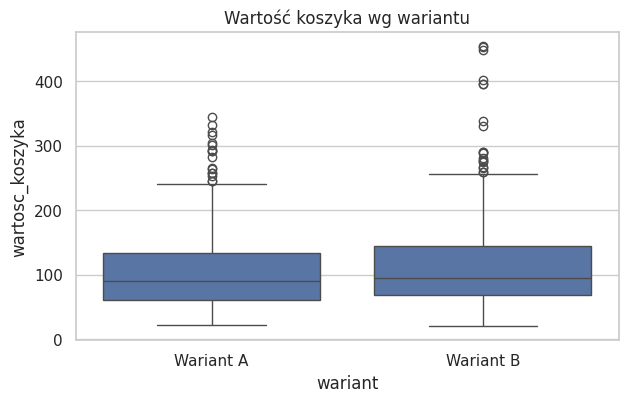

Shapiro A: 1.8252380527409868e-15
Shapiro B: 2.3270122416634135e-17


In [20]:
wariant_a = rng.lognormal(mean=4.5, sigma=0.6, size=350)   # wartości koszyka — z natury prawoskośne
wariant_b = rng.lognormal(mean=4.6, sigma=0.6, size=340)

# KROK 1: eksploracja i sprawdzenie założeń
df_koszyk = pd.concat([
    pd.DataFrame({"wariant": "Wariant A", "wartosc_koszyka": wariant_a}),
    pd.DataFrame({"wariant": "Wariant B", "wartosc_koszyka": wariant_b}),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_koszyk, x="wariant", y="wartosc_koszyka", ax=ax)
ax.set_title("Wartość koszyka wg wariantu")
plt.show()

print("Shapiro A:", stats.shapiro(wariant_a).pvalue)
print("Shapiro B:", stats.shapiro(wariant_b).pvalue)
# dane finansowe/transakcyjne (wartości koszyka) niemal zawsze wychodzą nienormalne (prawoskośne)

In [21]:
# KROK 2: normalność złamana -> Mann-Whitney zamiast t-testu
mw = stats.mannwhitneyu(wariant_a, wariant_b, alternative="two-sided")
print(f"Mann-Whitney: p-value = {mw.pvalue:.4f}")

# KROK 3: wielkość efektu (dla Mann-Whitney: rank-biserial correlation zamiast Cohen's d)
n_a, n_b = len(wariant_a), len(wariant_b)
r_rank_biserial = 1 - (2 * mw.statistic) / (n_a * n_b)
print(f"Rank-biserial correlation: {r_rank_biserial:.4f}  (umowne progi jak Cohen's d: 0.1/0.3/0.5)")

# KROK 4: kontekst biznesowy obok statystyki
roznica_median = np.median(wariant_b) - np.median(wariant_a)
print(f"Różnica median: {roznica_median:.2f} ({roznica_median / np.median(wariant_a):.1%} wzrostu)")

Mann-Whitney: p-value = 0.0970
Rank-biserial correlation: 0.0730  (umowne progi jak Cohen's d: 0.1/0.3/0.5)
Różnica median: 4.50 (5.0% wzrostu)


### Wniosek z przykładu

Sam wynik `p-value` nie jest odpowiedzią na pytanie biznesowe — dopiero
połączenie: **czy wynik istotny (p-value) + jak duży (effect size) + jak
duży w jednostkach zrozumiałych biznesowo (różnica median/średnich w PLN)**
daje kompletną podstawę do decyzji "czy wdrażamy wariant B".

## Podsumowanie — którego testu użyć

| Sytuacja | Dane normalne | Dane nienormalne / porządkowe |
|---|---|---|
| 2 grupy niezależne | t-test (Welch) | Mann-Whitney U |
| 2 grupy sparowane | t-test sparowany | Wilcoxon signed-rank |
| 3+ grup niezależnych | ANOVA + Tukey HSD | Kruskal-Wallis (+ Dunn) |
| Zależność 2 zmiennych kategorycznych | chi-kwadrat (liczności ≥ 5) | dokładny test Fishera (małe liczności) |
| Korelacja, związek liniowy | Pearson | Spearman / Kendall |

Zanim uruchomisz którykolwiek z powyższych: (1) sprawdź założenia
(sekcja 2), (2) policz i zaraportuj wielkość efektu (sekcja 7), (3) jeśli
testów jest więcej niż jeden — skoryguj p-value (sekcja 8).